In [57]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display, Markdown
from rapidfuzz import process, fuzz
from scipy.sparse import hstack
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import unicodedata
import numpy as np
import pickle
import re

## 1. EDA

### 1.1. catalog data

In [58]:
# Load the generated data
df_cat = pd.read_csv('catalog.csv')

In [59]:
df_cat

,sku,title,description,category,material,origin_district,price_rwf,artisan_id
0,SKU-1000,Kigali Leather Boots,Handcrafted leather boots for men and women. l...,leather,Leather,Gicumbi,19592,ART-2
1,SKU-1001,Nyamirambo Leather Sandals,Traditional sandals made from genuine cowhide....,leather,Leather,Gicumbi,41048,ART-16
2,SKU-1002,Kigali Leather Handbag,Premium leather handbag shoulder bag purse wom...,leather,Leather,Bugesera,23289,ART-48
3,SKU-1003,Huye Leather Belt,Genuine leather belt cowhide strap men accesso...,leather,Leather,Kigali,16395,ART-38
4,SKU-1004,Musanze Leather Wallet,Slim leather wallet card holder purse men wome...,leather,Leather,Rubavu,9165,ART-2
...,...,...,...,...,...,...,...,...
395,SKU-1395,Beaded Necklace Kigali,Handmade beaded necklace African jewelry women...,jewellery,Beads,Bugesera,55422,ART-31
396,SKU-1396,Rwandan Bead Bracelet,Traditional bead bracelet wrist jewelry colorf...,jewellery,Beads,Kigali,36091,ART-25
397,SKU-1397,Huye Bead Earrings,Handcrafted bead earrings African earrings jew...,jewellery,Beads,Huye,52049,ART-37
398,SKU-1398,Gicumbi Bead Ring,Beaded ring finger jewelry handmade accessory....,jewellery,Beads,Musanze,43696,ART-2


In [62]:
df_cat.describe(include=['O'])

,sku,title,description,category,material,origin_district,artisan_id
count,400,400,400,400,400,400,400
unique,400,34,34,5,5,6,50
top,SKU-1383,Kigali Leather Boots,Handcrafted leather boots for men and women. l...,leather,Leather,Rubavu,ART-18
freq,1,12,12,96,96,74,17


In [63]:
df_cat.describe()

,price_rwf
count,400.000000
mean,39736.770000
std,19818.465412
min,5053.000000
25%,22570.000000
50%,39673.000000
75%,56933.750000
max,74616.000000


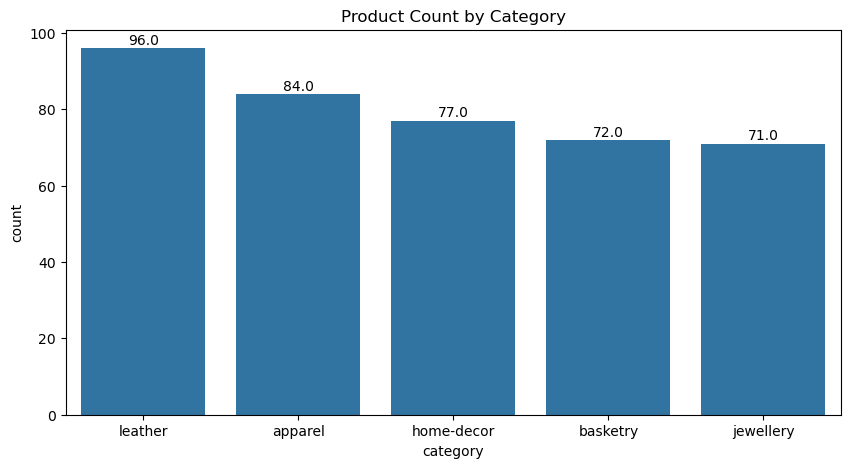

In [64]:
# 1. Visualize Category Distribution
plt.figure(figsize=(10,5))
ax = sns.countplot(data=df_cat, x='category', order=df_cat['category'].value_counts().index)
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x()+0.3, p.get_height()+1))
plt.title('Product Count by Category')
plt.show()

In [65]:
# 1. Get value counts of the categories
category_counts = df_cat['category'].value_counts()

# 2. Extract the top category name and its count
top_cat = category_counts.idxmax()
top_val = category_counts.max()
least_cat=category_counts.idxmin()
least_val=category_counts.min()

display(Markdown("---"))
display(Markdown("## **Catalog Summary**"))
display(Markdown(f"The largest category is **{top_cat}** with **{top_val}** items."))
display(Markdown(f"The smallest category is **{least_cat}** with **{least_val}** items."))
display(Markdown("*Other categories fall within this range to ensure a diverse 'Made in Rwanda' selection.*"))
display(Markdown(f"Total unique categories: **{df_cat['category'].nunique()}**"))



---

## **Catalog Summary**

The largest category is **leather** with **96** items.

The smallest category is **jewellery** with **71** items.

*Other categories fall within this range to ensure a diverse 'Made in Rwanda' selection.*

Total unique categories: **5**

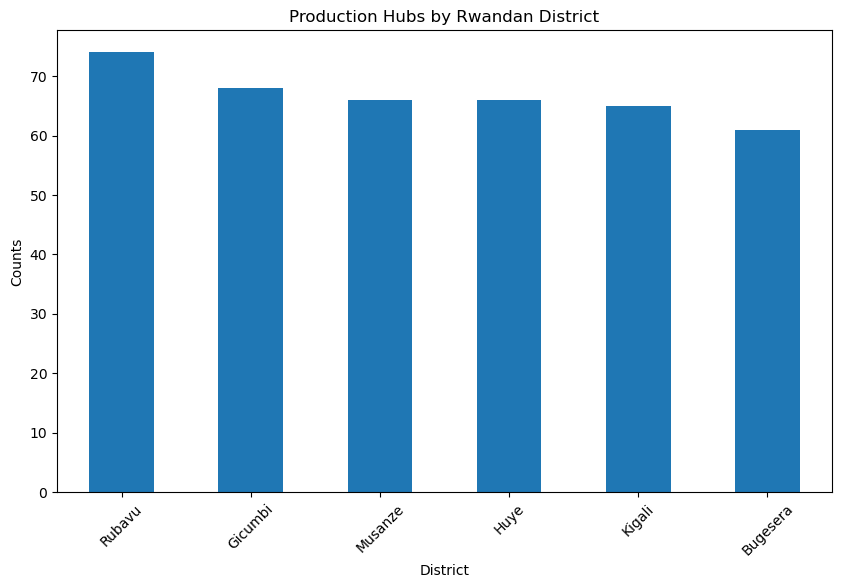

In [66]:
# District Distribution
plt.figure(figsize=(10, 6))
df_cat['origin_district'].value_counts().plot(kind='bar')
plt.title('Production Hubs by Rwandan District')
plt.ylabel('Counts')
plt.xlabel('District')
plt.xticks(rotation=45)
plt.show()

In [67]:
# 1. Get value counts for districts
district_counts = df_cat['origin_district'].value_counts()

# 2. Extract top and bottom districts dynamically
top_dist = district_counts.idxmax()
top_dist_val = district_counts.max()
least_dist = district_counts.idxmin()
least_dist_val = district_counts.min()

# Use your existing variables
display(Markdown("---"))
display(Markdown("### 🌍 **Geographic Summary**"))
display(Markdown(f"The district with the most artisans is **{top_dist}** with **{top_dist_val}** products."))
display(Markdown(f"The district with the fewest artisans is **{least_dist}** with **{least_dist_val}** products."))
display(Markdown(f"Total unique Rwandan districts: **{df_cat['origin_district'].nunique()}**"))
display(Markdown("---"))

---

### 🌍 **Geographic Summary**

The district with the most artisans is **Rubavu** with **74** products.

The district with the fewest artisans is **Bugesera** with **61** products.

Total unique Rwandan districts: **6**

---

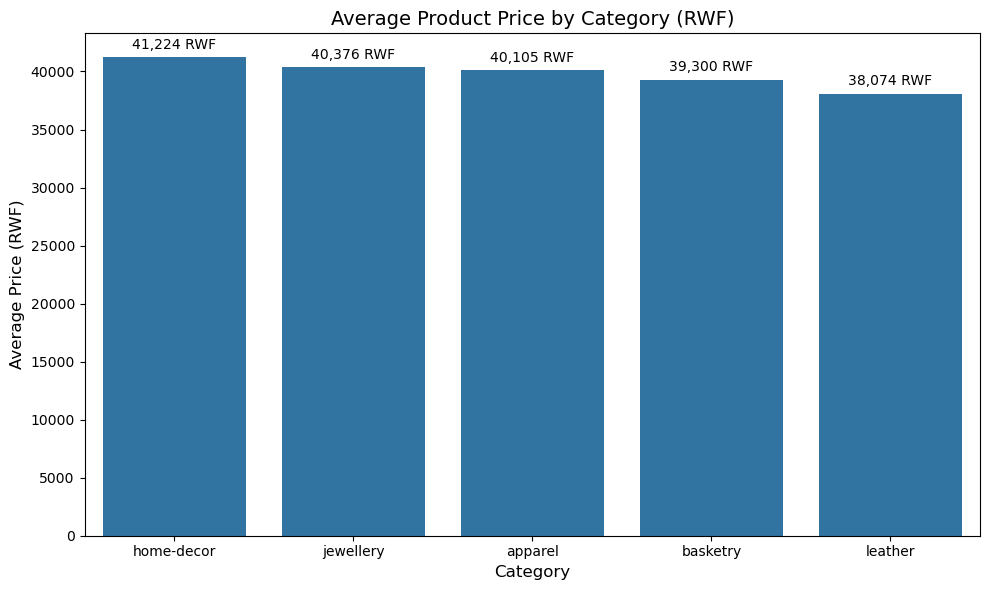

In [68]:
avg_price = df_cat.groupby('category')['price_rwf'].mean().sort_values(ascending=False).reset_index()

# Plotting
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=avg_price, x='category', y='price_rwf')

# Add labels and title
plt.title('Average Product Price by Category (RWF)', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Average Price (RWF)', fontsize=12)

# Annotate bars with the actual price values
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,} RWF', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=10)

plt.tight_layout()
plt.show()

In [69]:
# 1. Identify economic outliers
highest_avg_cat = avg_price.iloc[0]['category']
highest_avg_val = avg_price.iloc[0]['price_rwf']
lowest_avg_cat = avg_price.iloc[-1]['category']
lowest_avg_val = avg_price.iloc[-1]['price_rwf']
overall_avg = df_cat['price_rwf'].mean()

# 2. Dynamic Output
display(Markdown("---"))
display(Markdown("## **Economic Analysis: Price by Category**"))
display(Markdown(f"The most premium category on average is **{highest_avg_cat}** at **{int(highest_avg_val):,} RWF**."))
display(Markdown(f"The most accessible category on average is **{lowest_avg_cat}** at **{int(lowest_avg_val):,} RWF**."))
display(Markdown(f"The platform-wide average product price is **{int(overall_avg):,} RWF**."))


---

## **Economic Analysis: Price by Category**

The most premium category on average is **home-decor** at **41,224 RWF**.

The most accessible category on average is **leather** at **38,074 RWF**.

The platform-wide average product price is **39,736 RWF**.

In [70]:
# Artisan Concentration (Critical for the Fairness Cap task) [cite: 50]
top_artisans = df_cat['material'].value_counts()
print("Number of Materials:")
pd.DataFrame(top_artisans.reset_index())

Number of Materials:


,material,count
0,Leather,96
1,Cotton,84
2,Clay,77
3,Sisal,72
4,Beads,71


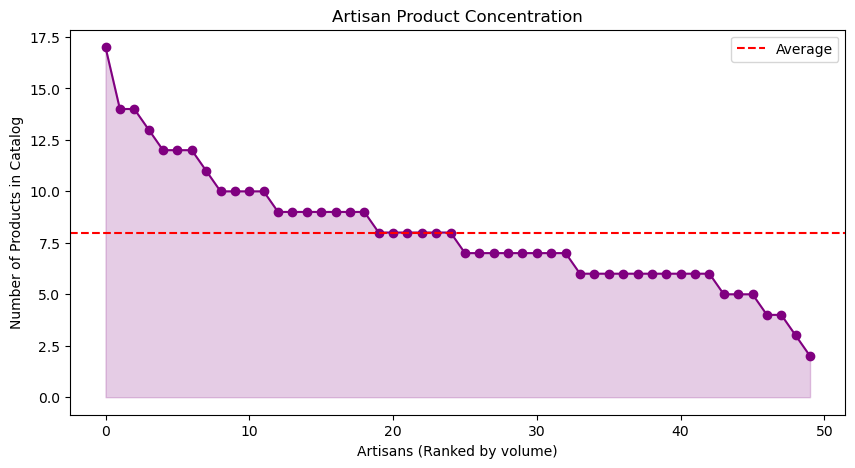

In [71]:
# Calculate product counts per artisan
artisan_counts = df_cat['artisan_id'].value_counts().sort_values(ascending=False)

# Plotting the distribution
plt.figure(figsize=(10, 5))
plt.plot(range(len(artisan_counts)), artisan_counts.values, marker='o', color='purple')
plt.fill_between(range(len(artisan_counts)), artisan_counts.values, color='purple', alpha=0.2)
plt.title('Artisan Product Concentration')
plt.xlabel('Artisans (Ranked by volume)')
plt.ylabel('Number of Products in Catalog')
plt.axhline(y=df_cat['artisan_id'].value_counts().mean(), color='r', linestyle='--', label='Average')
plt.legend()
plt.show()

In [72]:
from IPython.display import display, Markdown

# 1. Calculate Concentration Metrics
# Re-calculating to ensure we have the Series object with an index
artisan_counts_series = df_cat['artisan_id'].value_counts().sort_values(ascending=False)

total_artisans = len(artisan_counts_series)
top_artisan_id = artisan_counts_series.index[0] # This will now work
top_artisan_val = artisan_counts_series.max()
avg_products = artisan_counts_series.mean()

# Calculate % above average
percent_above_avg = (len(artisan_counts_series[artisan_counts_series > avg_products]) / total_artisans) * 100

# 2. Dynamic Output
display(Markdown("---"))
display(Markdown("## **Artisan Concentration & Fairness Analysis**"))
display(Markdown(f"There are **{total_artisans}** unique artisans represented in the 'Made in Rwanda' catalog."))
display(Markdown(f"The most active artisan is **{top_artisan_id}** with **{top_artisan_val}** products, representing **{(top_artisan_val/len(df_cat))*100:.1f}%** of the catalog."))
display(Markdown(f"On average, each artisan has **{avg_products:.1f}** products. Approximately **{percent_above_avg:.1f}%** of artisans are performing above this average."))
display(Markdown(f"> **Niche-First Impact:** The 'Long Tail' on the right of the graph represents artisans with only a few products. These are our primary targets for 'local-boost' nudging to ensure small-scale producers receive recommendation leads."))
display(Markdown("---"))

---

## **Artisan Concentration & Fairness Analysis**

There are **50** unique artisans represented in the 'Made in Rwanda' catalog.

The most active artisan is **ART-18** with **17** products, representing **4.2%** of the catalog.

On average, each artisan has **8.0** products. Approximately **38.0%** of artisans are performing above this average.

> **Niche-First Impact:** The 'Long Tail' on the right of the graph represents artisans with only a few products. These are our primary targets for 'local-boost' nudging to ensure small-scale producers receive recommendation leads.

---

In [73]:
def gini(x):
    # Ensure data is sorted
    x = np.sort(x)
    n = len(x)
    index = np.arange(1, n + 1)
    return (np.sum((2 * index - n - 1) * x)) / (n * np.sum(x))

artisan_counts = df_cat['artisan_id'].value_counts().values
gini_val = gini(artisan_counts)
print(f"Gini Coefficient of Artisan Distribution: {gini_val:.4f}")

Gini Coefficient of Artisan Distribution: 0.1985


### 1.2. queries data

In [74]:
df_queries = pd.read_csv('queries.csv')

In [75]:
df_queries

,query,global_best_match
0,leather boots,Kigali Leather Boots
1,inkweto z'uruhu,Kigali Leather Boots
2,leather handbag,Kigali Leather Handbag
3,impano yacu leather,Kigali Leather Handbag
4,panier tressé,Agaseke Peace Basket
...,...,...
115,impano yacu leather,Kigali Leather Handbag
116,leather shoes,Kigali Leather Shoes
117,leather handbag,Kigali Leather Handbag
118,lether bag,Kigali Leather Handbag


In [76]:
# 1. Define the Logic: Detect Language Intent
def categorize_query(q):
    """Categorizes queries into language groups based on keyword presence."""
    q = str(q).lower()
    # French keywords common in 'Made in Rwanda' trade
    if any(word in q for word in ['pour', 'femme', 'homme', 'cuir', 'cadeau', 'chaussure']): 
        return 'French'
    # Kinyarwanda/Code-switched keywords
    if any(word in q for word in ['yacu', 'iwacu', 'urwanda', 'inkweto', 'isoko']): 
        return 'Kinyarwanda/Code-switched'
    # Default to English/Mixed
    return 'English/General'

# 2. Process the Data
# Load the dataset (Ensure queries.csv is in your directory)
df_queries = pd.read_csv('queries.csv')

# Apply the function to create a new metadata column
df_queries['lang_group'] = df_queries['query'].apply(categorize_query)

# Generate the counts for the summary
lang_counts = df_queries['lang_group'].value_counts()

# 3. Professional Display Output
display(Markdown("---"))
display(Markdown("## 🔍 **Query Intent Analysis**"))
display(Markdown(f"The evaluation set contains **{len(df_queries)}** anonymized search queries."))

# Safely extract counts for the breakdown
fr_count = lang_counts.get('French', 0)
kinya_count = lang_counts.get('Kinyarwanda/Code-switched', 0)
en_count = lang_counts.get('English/General', 0)

display(Markdown(f"""
### **Linguistic Breakdown:**
* **French Intent:** {fr_count} queries
* **Kinyarwanda / Code-switched:** {kinya_count} queries
* **English / General:** {en_count} queries

**Primary language group:** `{lang_counts.idxmax()}`
"""))

display(Markdown("> **Methodology Note:** Identifying the language intent justifies the use of a **multilingual TF-IDF vectorizer** that accounts for local synonyms and regional spelling variations."))
display(Markdown("---"))

---

## 🔍 **Query Intent Analysis**

The evaluation set contains **120** anonymized search queries.


### **Linguistic Breakdown:**
* **French Intent:** 10 queries
* **Kinyarwanda / Code-switched:** 8 queries
* **English / General:** 102 queries

**Primary language group:** `English/General`


> **Methodology Note:** Identifying the language intent justifies the use of a **multilingual TF-IDF vectorizer** that accounts for local synonyms and regional spelling variations.

---

### 1.3. Click data

In [77]:
# 1. Data reading
df_clicks = pd.read_csv('click_log.csv')

##### User Behavior & Position Bias

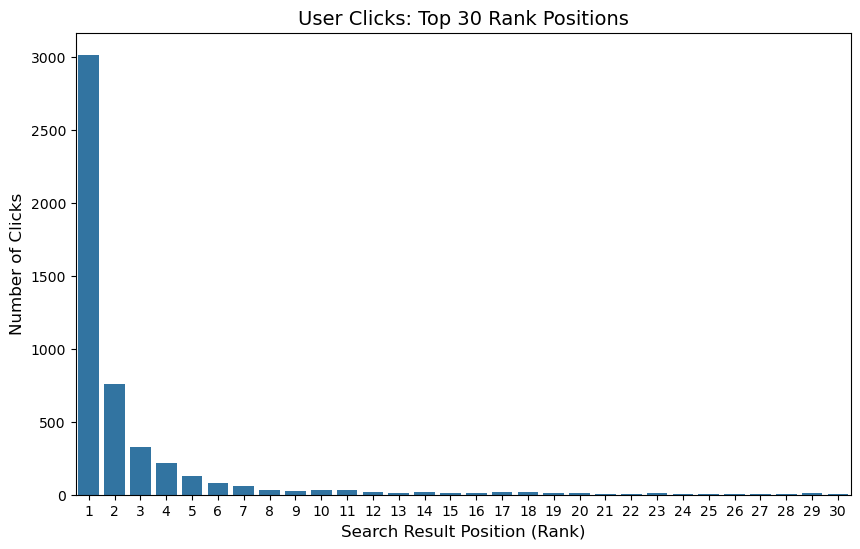

---

## **User Behavior: Position Bias Analysis**

**60.3%** of all clicks occur at **Position 1**, with a sharp decay thereafter.

The average click position is **3.47**.

> **Critical Insight:** The 'Graveyard' effect is real—products below position 30 receive virtually zero traffic. 
> To fulfill the 'Made in Rwanda' mission, our **Local-Boost** rule must successfully inject local artisans into these top-tier slots.

---

In [78]:
top_n = 30
df_top_clicks = df_clicks[df_clicks['position'] <= top_n]

# 2. Plotting (The "Clean" Version)
plt.figure(figsize=(10, 6))
sns.countplot(data=df_top_clicks, x='position')
plt.title(f'User Clicks: Top {top_n} Rank Positions', fontsize=14)
plt.xlabel('Search Result Position (Rank)', fontsize=12)
plt.ylabel('Number of Clicks', fontsize=12)
plt.show()

# 3. Dynamic Summary
top_1_ratio = (len(df_clicks[df_clicks['position'] == 1]) / len(df_clicks)) * 100
avg_pos = df_clicks['position'].mean()

display(Markdown("---"))
display(Markdown("## **User Behavior: Position Bias Analysis**"))
display(Markdown(f"**{top_1_ratio:.1f}%** of all clicks occur at **Position 1**, with a sharp decay thereafter."))
display(Markdown(f"The average click position is **{avg_pos:.2f}**."))
display(Markdown(f"""> **Critical Insight:** The 'Graveyard' effect is real—products below position {top_n} receive virtually zero traffic. 
> To fulfill the 'Made in Rwanda' mission, our **Local-Boost** rule must successfully inject local artisans into these top-tier slots."""))
display(Markdown("---"))

## 2. Vectorization Pipeline

In [79]:
df_cat = df_cat.drop_duplicates(subset='title', keep='first').reset_index(drop=True)
# ── STEP 1: STOPWORDS ──────────────────────────────────────────────────────────
STOPWORDS = {'à', 'en', 'de', 'le', 'la', 'les', 'du', 'un', 'une', 'pour', 'et'}

# ── STEP 2: TRANSLATION DICTIONARIES ──────────────────────────────────────────
FR_EN = {
    'cuir': 'leather', 'bottes': 'boots', 'sac': 'bag',
    'main': 'handbag', 'robe': 'dress', 'panier': 'basket',
    'tressé': 'woven', 'perles': 'beads', 'bracelet': 'bracelet',
    'cadeau': 'gift', 'femme': 'women', 'homme': 'men',
    'chaussures': 'shoes', 'collier': 'necklace', 'bague': 'ring',
    'africaine': 'african', 'fait': 'handmade',
}
KIN_EN = {
    'inkweto': 'shoes boots', 'impano': 'gift',
    'uruhu': 'leather', 'agaseke': 'agaseke basket woven',
    'yacu': 'local rwandan',
}

# ── STEP 3: WEIGHTED METADATA ──────────────────────────────────────────────────
df_cat['metadata'] = (
    (df_cat['title'] + " ") * 3 +
    (df_cat['category'] + " ") * 2 +
    df_cat['description'] + " " +
    df_cat['material']
).fillna('')

# Patch basketry so "woven/panier/tressé" queries can find it
df_cat.loc[df_cat['category'] == 'basketry', 'metadata'] += \
    ' woven tressé panier basket agaseke sisal weave'

# ── STEP 4: VOCAB (must be built AFTER metadata) ───────────────────────────────
vocab = set(' '.join(df_cat['metadata'].str.lower()).split())

# ── STEP 5: QUERY PIPELINE FUNCTIONS ──────────────────────────────────────────
def translate_query(query):
    words = query.lower().split()
    translated = []
    for w in words:
        translated.append(FR_EN.get(w, KIN_EN.get(w, w)))
    return ' '.join(translated)

def preprocess_query(query):
    words = query.lower().split()
    corrected = []
    for word in words:
        if word in vocab:
            corrected.append(word)
        else:
            match, score, _ = process.extractOne(word, vocab, scorer=fuzz.ratio)
            corrected.append(match if score >= 65 else word)
    return ' '.join(corrected)

def full_query_pipeline(query):
    q = translate_query(query)                                 # FR/KIN → EN
    q = ' '.join(w for w in q.split() if w not in STOPWORDS)  # remove stopwords
    q = preprocess_query(q)                                    # fix typos
    return q

# ── STEP 6: HYBRID VECTORIZER ──────────────────────────────────────────────────
tfidf_word = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    lowercase=True,
    max_features=8000,
    sublinear_tf=True       # dampens high-frequency terms
)
tfidf_char = TfidfVectorizer(
    analyzer='char_wb',
    ngram_range=(3, 5),
    lowercase=True,
    max_features=8000,
    sublinear_tf=True
)

word_matrix = tfidf_word.fit_transform(df_cat['metadata'])
char_matrix = tfidf_char.fit_transform(df_cat['metadata'])
tfidf_matrix = hstack([word_matrix, char_matrix])  # shape: (400, word_feats + char_feats)

print(f"Hybrid index built: {tfidf_matrix.shape}")

# ── STEP 7: QUERY VECTORIZER FUNCTION ─────────────────────────────────────────
def vectorize_query(query):
    clean = full_query_pipeline(query)
    return hstack([
        tfidf_word.transform([clean]),
        tfidf_char.transform([clean])
    ])

# ── STEP 8: SAVE EVERYTHING ────────────────────────────────────────────────────
with open('tfidf_model.pkl', 'wb') as f:
    pickle.dump((tfidf_word, tfidf_char, tfidf_matrix, vocab, FR_EN, KIN_EN), f)

print("✅ Model saved")

Hybrid index built: (34, 2085)
✅ Model saved


## 3. Scientific Proof (NDCG@5)

In [80]:

def calculate_ndcg_at_5_robust(query_vec, catalog_matrix, target_sku, catalog_df):
    sims = cosine_similarity(query_vec, catalog_matrix).flatten()
    # Get top 5
    top_5_idx = sims.argsort()[-5:][::-1]
    top_5_skus = catalog_df.iloc[top_5_idx]['sku'].values
    
    if target_sku in top_5_skus:
        # Find the rank (0 to 4)
        rank = np.where(top_5_skus == target_sku)[0][0] + 1
        return 1.0 / np.log2(rank + 1)
    return 0.0

In [81]:
scores = []
misses = []

for _, row in df_queries.iterrows():
    target_sku_res = df_cat[df_cat['title'].str.contains(
        ' '.join(row['global_best_match'].split()[:3]), case=False, na=False
    )]
    if not target_sku_res.empty:
        target_sku = str(target_sku_res.iloc[0]['sku'])
        
        clean_query = full_query_pipeline(row['query'])
        q_vec = vectorize_query(row['query'])          # ← was: tfidf.transform([clean_query])
        
        sims = cosine_similarity(q_vec, tfidf_matrix).flatten()
        all_ranked = sims.argsort()[::-1]
        target_idx = df_cat[df_cat['sku'].astype(str) == target_sku].index
        
        if len(target_idx) > 0:
            actual_rank = np.where(all_ranked == target_idx[0])[0]
            if len(actual_rank) > 0:
                misses.append({
                    'query': row['query'],
                    'clean_query': clean_query,
                    'target': row['global_best_match'],
                    'actual_rank': actual_rank[0] + 1
                })
        
        scores.append(calculate_ndcg_at_5_robust(
            q_vec, tfidf_matrix, target_sku, df_cat  # ← df_cat not df
        ))

avg_ndcg = np.mean(scores) if scores else 0
print(f"Final NDCG@5: {avg_ndcg:.4f}")
print(f"Evaluated on {len(scores)} queries")

ranks = [m['actual_rank'] for m in misses if 'actual_rank' in m]
display(f"Avg actual rank of target: {np.mean(ranks):.1f}")
display(f"% in top 5: {np.mean([r <= 5 for r in ranks]):.2%}")
display(pd.DataFrame(misses).head(10))

Final NDCG@5: 0.9155
Evaluated on 120 queries


'Avg actual rank of target: 1.3'

'% in top 5: 97.50%'

,query,clean_query,target,actual_rank
0,leather boots,leather boots,Kigali Leather Boots,1
1,inkweto z'uruhu,shoes boots z'uruhu,Kigali Leather Boots,1
2,leather handbag,leather handbag,Kigali Leather Handbag,1
3,impano yacu leather,gift local rwandan leather,Kigali Leather Handbag,4
4,panier tressé,basket woven,Agaseke Peace Basket,1
5,wood sculpture,wood sculpture,Musanze Wood Sculpture,1
6,clay vase,clay vase,Clay Vase Bugesera,1
7,impano yacu leather,gift local rwandan leather,Kigali Leather Handbag,4
8,neklace beads,necklace beads,Beaded Necklace Kigali,1
9,clay vase,clay vase,Clay Vase Bugesera,1


In [82]:
print(f"tfidf_matrix rows : {tfidf_matrix.shape[0]}")
print(f"catalog rows      : {len(df_cat)}")

tfidf_matrix rows : 34
catalog rows      : 34
